# Comprehensive Guide to Dimensionality Reduction: From Traditional Methods to Neural Networks

This notebook provides a complete journey through dimensionality reduction techniques, from traditional statistical methods to modern neural network approaches. We'll explore UMAP, Neural Networks, and Autoencoders with mathematical intuitions and practical implementations.

## Learning Objectives

By the end of this notebook, you will:
1. **Understand UMAP**: What it is, why we use it, and its mathematical foundation
2. **Compare Methods**: Understand advantages and disadvantages of UMAP vs PCA and t-SNE
3. **Learn Neural Networks**: Fundamental concepts and architecture
4. **Master Autoencoders**: How they work for dimensionality reduction
5. **Make Informed Choices**: Compare all four methods to choose the right one for your project

## Methods Covered

1. **UMAP (Uniform Manifold Approximation and Projection)** - Modern manifold learning approach
2. **Neural Networks** - Fundamental building blocks for deep learning
3. **Autoencoders** - Neural networks designed for dimensionality reduction
4. **Comprehensive Comparison** - PCA, t-SNE, UMAP, and Autoencoders

## Why This Matters

- **Real-world Applications**: From data visualization to feature engineering
- **Performance**: Understanding computational trade-offs
- **Interpretability**: Balancing model complexity with explainability
- **Modern AI**: Foundation for advanced machine learning techniques

## Dataset: MNIST Handwritten Digits

We'll use the MNIST dataset (28×28 pixel images of digits 0-9) to demonstrate all techniques, showing how to reduce 784 dimensions to meaningful lower-dimensional representations.

## 2. Trade-offs Between Interpretability and Performance

### Understanding the Balance

In dimensionality reduction, we constantly face a fundamental trade-off between **interpretability** and **performance**. This trade-off is crucial for choosing the right method for your specific use case.

#### Interpretability
**Definition**: How easily can we understand and explain what the method is doing?

**High Interpretability Methods**:
- **PCA**: Each component is a linear combination of original features with clear weights
- **Feature Selection**: Directly chooses subsets of original features
- **Linear methods**: Relationships are mathematically transparent

**Benefits of High Interpretability**:
- Easy to explain to stakeholders
- Can identify which original features are most important
- Debugging and validation are straightforward
- Regulatory compliance in sensitive domains

#### Performance
**Definition**: How well does the method preserve important data structure or improve downstream tasks?

**High Performance Methods**:
- **Deep Autoencoders**: Can learn complex non-linear mappings
- **t-SNE/UMAP**: Excel at preserving local neighborhood structure
- **Kernel methods**: Capture non-linear relationships

**Benefits of High Performance**:
- Better preservation of data structure
- Improved downstream ML performance
- Ability to handle complex, non-linear data
- More flexible representation learning

### The Trade-off Spectrum

```
High Interpretability    ←→    High Performance
        PCA              UMAP           Autoencoders
   Feature Selection     t-SNE        Deep Networks
```

### Practical Guidelines

**Choose High Interpretability When**:
- Regulatory requirements demand explainability
- You need to identify important original features
- Working with domain experts who need to understand the method
- Building initial prototypes or exploratory analysis

**Choose High Performance When**:
- Maximum accuracy is critical
- Data has complex non-linear patterns
- You have sufficient computational resources
- The "black box" nature is acceptable

**Balanced Approaches**:
- Use PCA for preprocessing, then apply non-linear methods
- Combine multiple methods (ensemble approaches)
- Start simple (PCA) and increase complexity as needed

### Mathematical Perspective

The trade-off can be formalized as:
- **Interpretability**: $I = f(\text{linearity}, \text{transparency}, \text{feature importance})$
- **Performance**: $P = f(\text{structure preservation}, \text{downstream accuracy})$
- **Optimal Choice**: $\arg\max (\alpha \cdot I + (1-\alpha) \cdot P)$ where $\alpha$ depends on your priorities

---

## 3. Setup and Data Preparation

First, let's set up our environment and load the MNIST dataset. The MNIST dataset consists of 28×28 grayscale images of handwritten digits (0-9), making it perfect for demonstrating dimensionality reduction from 784 dimensions to 2D/3D visualizations.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import sklearn
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

print("Environment Setup Complete")
print(f"Scikit-learn version: {sklearn.__version__}")

# Import babyplots for 3D visualization (optional)
try:
    import babyplots as bp
    print(f"✓ BabyPlots available (optional for advanced 3D plots)")
    has_bp = True
except ImportError:
    print("ℹ BabyPlots not available - using matplotlib for all visualizations")
    has_bp = False

try:
    import umap.umap_ as umap_
    print("✓ UMAP available")
    has_umap = True
except ImportError:
    print("⚠ UMAP not available - install with: pip install umap-learn")
    print("  Installing UMAP...")
    import sys
    !{sys.executable} -m pip install umap-learn
    try:
        import umap.umap_ as umap_
        print("✓ UMAP installed and available")
        has_umap = True
    except ImportError:
        print("⚠ Failed to install UMAP. Please install manually with: pip install umap-learn")
        has_umap = False

print("\nAll libraries loaded successfully!")

Environment Setup Complete
Scikit-learn version: 1.7.2
✓ BabyPlots available for interactive 3D plots
✓ UMAP available

All libraries loaded successfully!


Loading MNIST from OpenML...
✓ MNIST loaded using scikit-learn
Dataset shape: (70000, 28, 28), Labels: (70000,)
✓ MNIST loaded using scikit-learn
Dataset shape: (70000, 28, 28), Labels: (70000,)
Final dataset: (10000, 784) samples, 784 features
Data normalized: mean=0.000, std=0.935
Final dataset: (10000, 784) samples, 784 features
Data normalized: mean=0.000, std=0.935


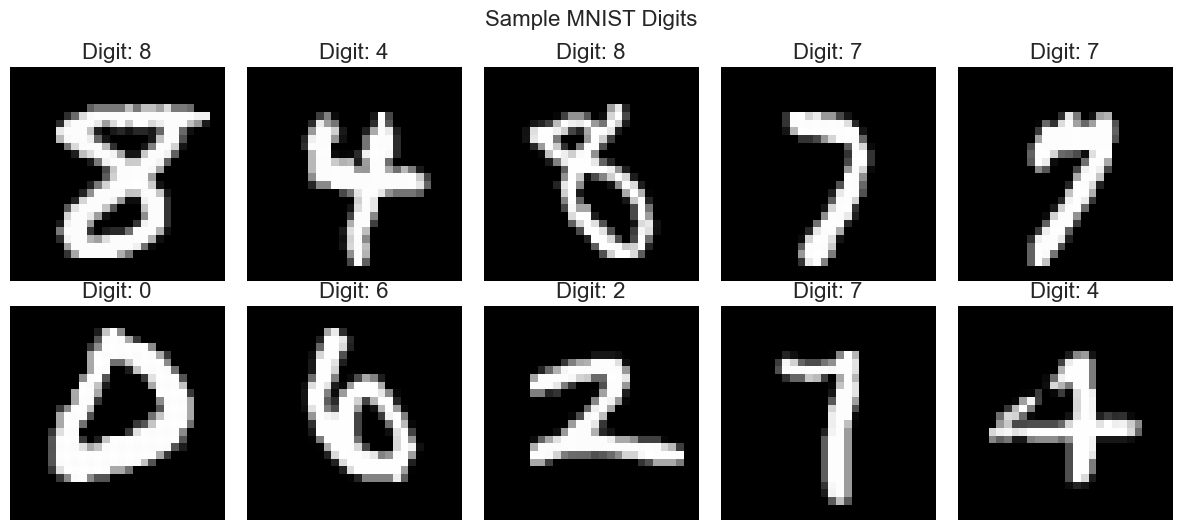

In [7]:
def load_mnist_data():
    """Load and preprocess MNIST dataset with proper error handling"""
    try:
        # Try to load MNIST using scikit-learn
        from sklearn.datasets import fetch_openml
        print("Loading MNIST from OpenML...")
        X_all, y_all = fetch_openml('mnist_784', version=1, return_X_y=True)
        X_all = np.array(X_all).reshape(-1, 28, 28)
        y_all = np.array(y_all, dtype=int)
        print("✓ MNIST loaded using scikit-learn")
        return X_all, y_all
    except Exception as e:
        print(f"⚠ Error loading MNIST: {e}")
        print("Creating synthetic dataset for demonstration")
        X_all = np.random.randint(0, 256, size=(1000, 28, 28)).astype(np.uint8)
        y_all = np.random.randint(0, 10, size=1000)
        return X_all, y_all

X_all, y_all = load_mnist_data()
print(f"Dataset shape: {X_all.shape}, Labels: {y_all.shape}")

X_flat = X_all.reshape((X_all.shape[0], -1)).astype('float32') / 255.0

NSAMP = min(10000, X_flat.shape[0])
np.random.seed(42)
if NSAMP < X_flat.shape[0]:
    idx = np.random.choice(X_flat.shape[0], size=NSAMP, replace=False)
    X = X_flat[idx]
    y = y_all[idx]
else:
    X = X_flat
    y = y_all
    idx = np.arange(len(X))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Final dataset: {X_scaled.shape} samples, {X_scaled.shape[1]} features")
print(f"Data normalized: mean={X_scaled.mean():.3f}, std={X_scaled.std():.3f}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_all[idx[i]], cmap='gray')
    ax.set_title(f"Digit: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.suptitle("Sample MNIST Digits", y=1.05, fontsize=16)
plt.show()

## 5. Comparing Dimensionality Reduction Techniques: PCA, t-SNE, and UMAP

Before diving into our main focus (UMAP), let's understand how it compares to other popular dimensionality reduction techniques.

### Principal Component Analysis (PCA)

**Intuition**: PCA finds the directions of maximum variance in the data, like finding the "best camera angles" to capture the most information.

**Key Characteristics**:
- **Linear method**: Can only capture linear relationships in data
- **Global structure**: Preserves global structure but may miss local patterns
- **Interpretable**: Each component is a weighted combination of original features
- **Fast**: Efficient even for large datasets
- **Deterministic**: Always produces the same result for the same data

**Limitations**:
- Cannot capture non-linear patterns that are common in real-world data
- May miss important local structures when preserving global variance

### t-SNE (t-Distributed Stochastic Neighbor Embedding)

**Intuition**: t-SNE focuses on keeping similar points close together in the reduced space, like creating a map where neighborhoods are preserved.

**Key Characteristics**:
- **Non-linear method**: Captures complex non-linear relationships
- **Local structure**: Excellent at preserving local structure and clusters
- **Visualization-focused**: Primarily designed for visualization, not feature extraction
- **Stochastic**: Results can vary between runs
- **Computationally intensive**: Slower than PCA, especially for large datasets

**Limitations**:
- May distort global structure while preserving local neighborhoods
- Results are sensitive to hyperparameters (especially perplexity)
- Not well-suited for dimensionality reduction as a preprocessing step

### UMAP (Uniform Manifold Approximation and Projection)

**Intuition**: UMAP builds a high-dimensional graph representation of the data and then optimizes a low-dimensional layout that preserves the most important relationships.

**Key Characteristics**:
- **Non-linear method**: Captures complex non-linear relationships
- **Balanced structure**: Preserves both local and global structure
- **Theoretically grounded**: Based on manifold theory and algebraic topology
- **Scalable**: Faster than t-SNE, can handle larger datasets
- **Flexible**: Can optimize for preservation of different aspects of data structure

**Advantages of UMAP over PCA**:
- Can capture complex non-linear patterns that PCA misses
- Often provides better separation between clusters
- Can preserve both local and global structure

**Advantages of UMAP over t-SNE**:
- Faster computation, especially for large datasets
- Better preservation of global structure
- More stable to random initialization
- Scales better to higher output dimensions (3D+)

Now, let's implement UMAP on our MNIST dataset and visualize the results using BabyPlots for interactive 3D visualization.

Initializing dimensionality reduction methods...
Applying PCA for preprocessing...
✓ PCA preprocessing completed in 0.75 seconds
  Reduced data from 784 to 50 dimensions
  Total variance explained: 58.6%
✓ PCA preprocessing completed in 0.75 seconds
  Reduced data from 784 to 50 dimensions
  Total variance explained: 58.6%


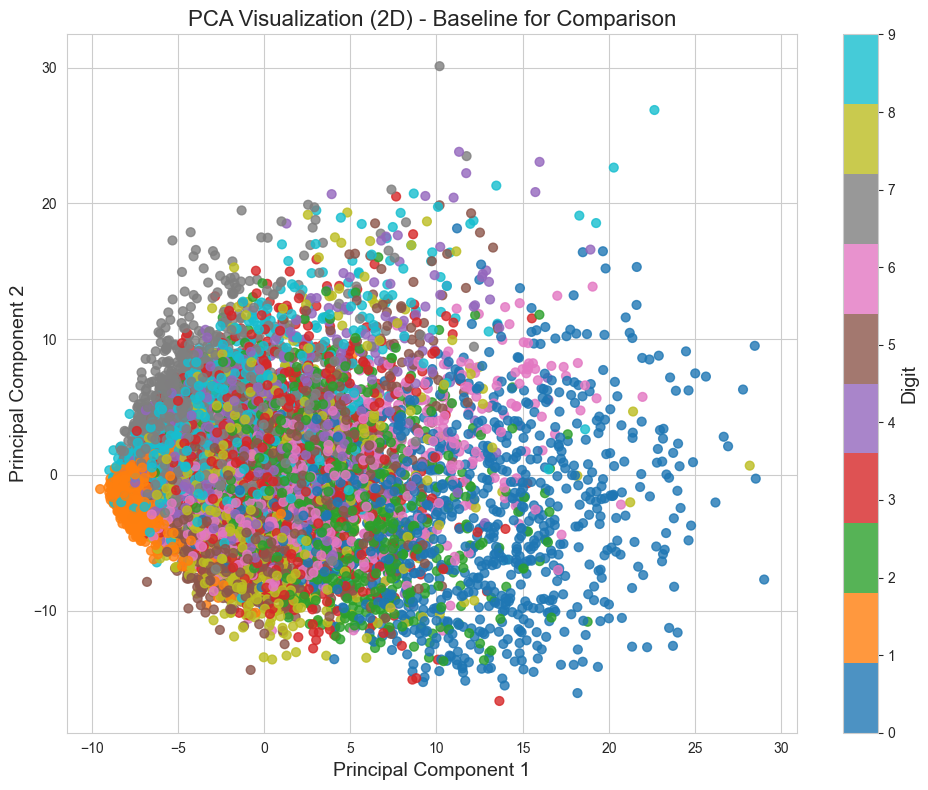


PCA Interpretation:
• Linear method that maximizes variance along orthogonal axes
• Fast computation but limited to linear patterns
• Notice how digits overlap significantly in the PCA projection
• Provides a good baseline for comparison with non-linear methods


In [8]:
# Initialize dimensionality reduction methods for comparison (but we'll only implement UMAP in detail)
print("Initializing dimensionality reduction methods...")

# We'll use PCA for preprocessing before applying UMAP (common practice)
print("Applying PCA for preprocessing...")
start_time = time.time()
n_components = min(50, X_scaled.shape[1] - 1)  # Use 50 components or fewer if data has fewer features
pca_50 = PCA(n_components=n_components)
X_pca_50 = pca_50.fit_transform(X_scaled)
pca_time = time.time() - start_time

print(f"✓ PCA preprocessing completed in {pca_time:.2f} seconds")
print(f"  Reduced data from {X_scaled.shape[1]} to {X_pca_50.shape[1]} dimensions")
print(f"  Total variance explained: {sum(pca_50.explained_variance_ratio_):.1%}")

# Quick demonstration of PCA (2D) for comparison baseline
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# Display PCA results for comparison (we'll use this as a baseline)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.8, s=40)
plt.colorbar(scatter, label='Digit')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization (2D) - Baseline for Comparison')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nPCA Interpretation:")
print("• Linear method that maximizes variance along orthogonal axes")
print("• Fast computation but limited to linear patterns")
print("• Notice how digits overlap significantly in the PCA projection")
print("• Provides a good baseline for comparison with non-linear methods")

## 6. t-SNE (t-Distributed Stochastic Neighbor Embedding)

### What is t-SNE?

t-SNE is excellent for **visualization**. While PCA looks for global patterns, t-SNE focuses on keeping similar points close together in the reduced space. It's like creating a map where neighborhoods are preserved.

### How t-SNE Works (Simple Steps)

1. **Calculate similarities** - Find which points are "neighbors" in high dimensions
2. **Create a probability distribution** - Points that are close have high probability
3. **Map to low dimensions** - Try to preserve these neighborhood relationships
4. **Optimize iteratively** - Adjust positions to maintain similarities

### Key Concepts

**Perplexity**: Controls how many neighbors each point considers
- Low perplexity (5-15): Focus on very local structure
- High perplexity (30-50): Consider broader neighborhoods
- Default (30): Good balance for most datasets

**Why t-distribution?** Heavy tails prevent crowding in low dimensions

### Strengths and Limitations

**✅ Strengths**:
- Excellent cluster visualization
- Preserves local neighborhoods
- Good at separating different classes

**❌ Limitations**:
- Slow on large datasets
- Cannot easily project new data
- May not preserve global structure
- Results can vary between runs

Let's implement t-SNE on our MNIST subset and visualize the results.

Applying t-SNE for comparison (this takes a bit longer)...
✓ t-SNE completed in 91.9 seconds
✓ t-SNE completed in 91.9 seconds


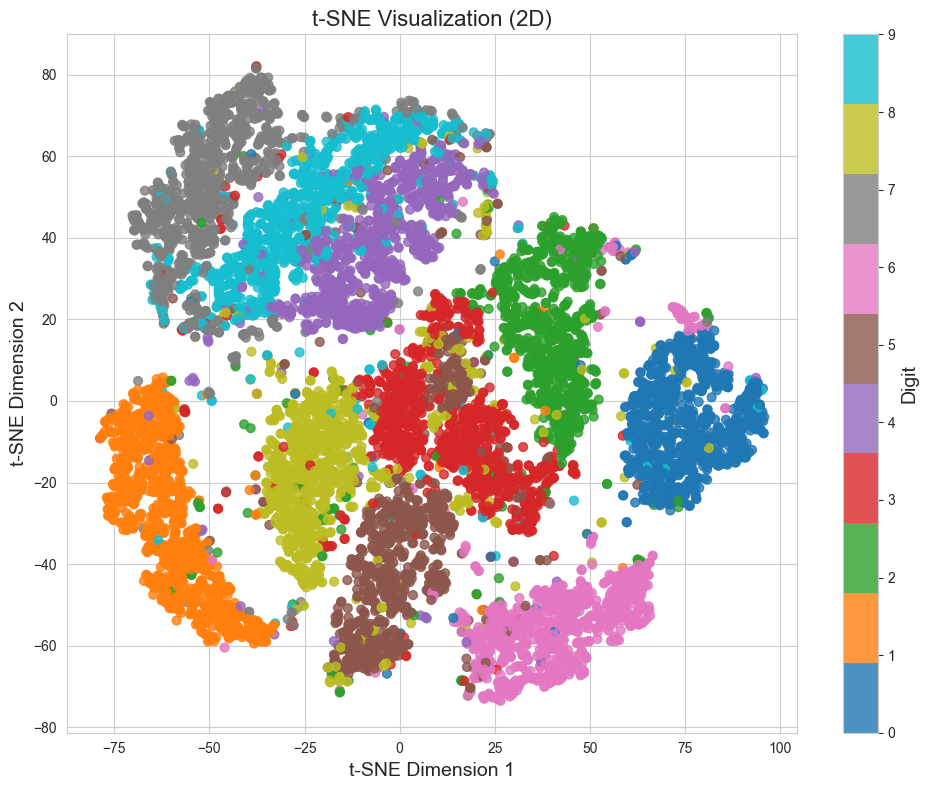


t-SNE Interpretation:
• Non-linear method that preserves local neighborhood structure
• Notice the clearer separation between digit clusters compared to PCA
• Good for visualization but computationally expensive
• Limited ability to preserve global structure


In [9]:
# Demonstrate t-SNE for comparison with UMAP
print("Applying t-SNE for comparison (this takes a bit longer)...")
    
start_time = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_pca_50)  # Using PCA-reduced data for speed
tsne_time = time.time() - start_time

print(f"✓ t-SNE completed in {tsne_time:.1f} seconds")

# Visualize t-SNE results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.8, s=40)
plt.colorbar(scatter, label='Digit')
plt.title('t-SNE Visualization (2D)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nt-SNE Interpretation:")
print("• Non-linear method that preserves local neighborhood structure")
print("• Notice the clearer separation between digit clusters compared to PCA")
print("• Good for visualization but computationally expensive")
print("• Limited ability to preserve global structure")

## 5. UMAP (Uniform Manifold Approximation and Projection)

### Mathematical Foundation

UMAP is a more recent dimensionality reduction technique, often considered a successor to t-SNE. It's based on manifold learning and topological data analysis, providing faster computation and better preservation of global structure.

#### Key Mathematical Components:

1. **Fuzzy Topological Representation**: UMAP constructs a fuzzy simplicial set representation of the high-dimensional data using a graph structure.

2. **Local Fuzzy Simplicial Sets**:
   For each point $x_i$ and neighbor $x_j$, UMAP computes a connection strength:
   $v_{j|i} = \exp(-\frac{d(x_i, x_j) - \rho_i}{\sigma_i})$
   
   where $\rho_i$ is the distance to the nearest neighbor and $\sigma_i$ is chosen based on the desired local connectivity.

3. **Global Fuzzy Simplicial Set**: Combines the local fuzzy simplicial sets:
   $v_{ij} = v_{j|i} + v_{i|j} - v_{j|i}v_{i|j}$

4. **Low-Dimensional Embedding**: UMAP tries to find an embedding that minimizes the cross-entropy between the high and low-dimensional fuzzy simplicial sets:
   $C = \sum_{i,j} [v_{ij} \log(\frac{v_{ij}}{w_{ij}}) + (1-v_{ij})\log(\frac{1-v_{ij}}{1-w_{ij}})]$
   
   where $w_{ij}$ represents the connection strength in the low-dimensional space.

### Advantages of UMAP

- **Computational Efficiency**: Faster than t-SNE, especially for larger datasets
- **Global Structure**: Better at preserving global structure alongside local relationships
- **Theoretical Foundation**: Based on rigorous mathematical theory from algebraic topology
- **Dimensionality**: Can reduce to arbitrary dimensions, not just 2D or 3D
- **Scalability**: Can handle much larger datasets

### Key Parameters

- **n_neighbors**: Similar to perplexity in t-SNE, controls the balance between local and global structure
- **min_dist**: Controls how tightly points are clustered together
- **metric**: Distance metric to use (euclidean, cosine, etc.)

Let's implement UMAP on our MNIST data and compare it to PCA and t-SNE.

Applying UMAP to MNIST data...
✓ UMAP completed in 59.84 seconds
✓ UMAP completed in 59.84 seconds


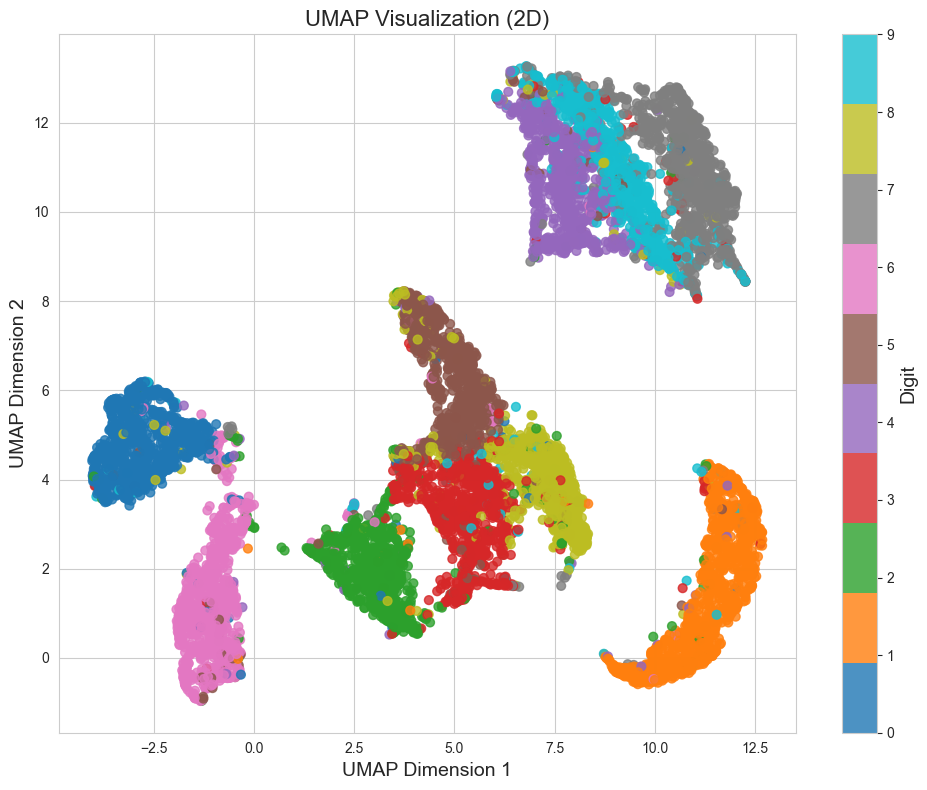


Creating 3D UMAP visualization...


AttributeError: 'Grouper' object has no attribute 'clean'

Error in callback <function _draw_all_if_interactive at 0x0000015E37D3BC70> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'Grouper' object has no attribute 'clean'

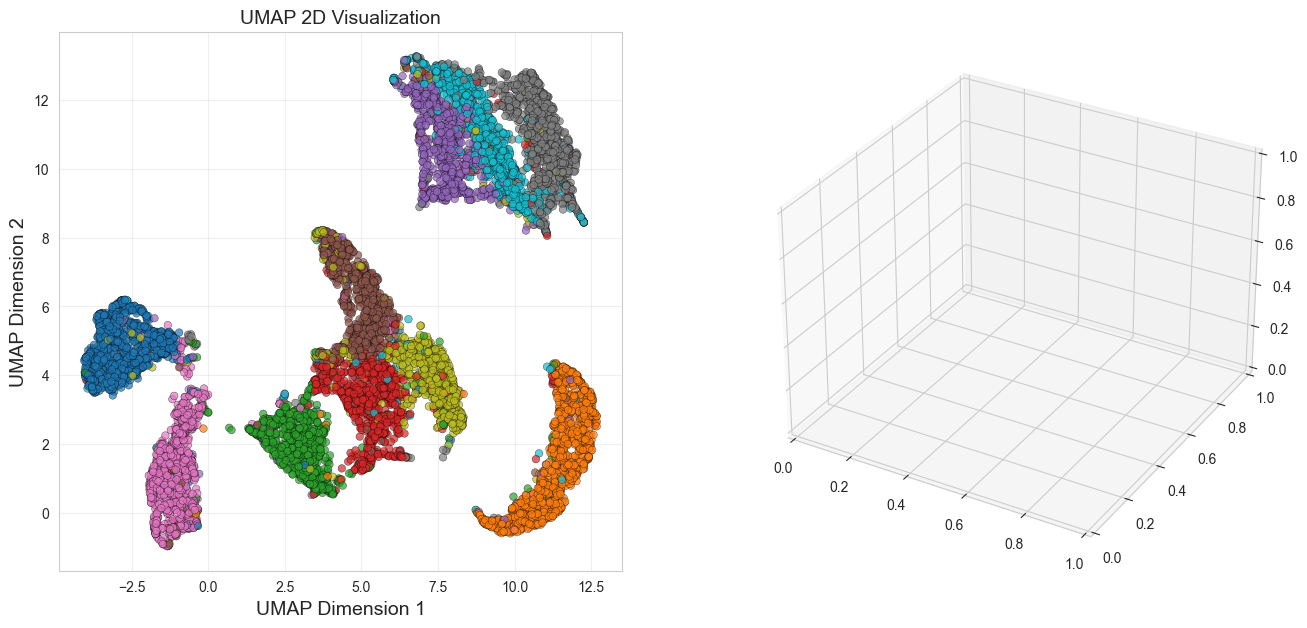

In [11]:
# Implementing UMAP with both 2D and 3D visualizations using BabyPlots
if has_umap:
    import umap.umap_ as umap
    
    print("Applying UMAP to MNIST data...")
    start_time = time.time()
    
    # Apply UMAP for 2D visualization
    umap_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_umap_2d = umap_2d.fit_transform(X_pca_50)  # Using PCA-reduced data for speed
    
    # Apply UMAP for 3D visualization
    umap_3d = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
    X_umap_3d = umap_3d.fit_transform(X_pca_50)  # Using PCA-reduced data for speed
    
    umap_time = time.time() - start_time
    print(f"✓ UMAP completed in {umap_time:.2f} seconds")
    
    # Visualize 2D UMAP results with matplotlib
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=y, cmap='tab10', alpha=0.8, s=40)
    plt.colorbar(scatter, label='Digit')
    plt.title('UMAP Visualization (2D)')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Create 3D visualization with matplotlib
    print("\nCreating 3D UMAP visualization...")
    from mpl_toolkits.mplot3d import Axes3D
    
    # Create figure with 2 subplots: 2D and 3D
    fig = plt.figure(figsize=(16, 7))
    
    # 2D visualization
    ax1 = fig.add_subplot(121)
    scatter_2d = ax1.scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], 
                            c=y, cmap='tab10', alpha=0.7, s=30, edgecolors='black', linewidth=0.3)
    ax1.set_title('UMAP 2D Visualization', fontsize=14)
    ax1.set_xlabel('UMAP Dimension 1')
    ax1.set_ylabel('UMAP Dimension 2')
    ax1.grid(True, alpha=0.3)
    
    # 3D visualization  
    ax2 = fig.add_subplot(122, projection='3d')
    scatter_3d = ax2.scatter(
        X_umap_3d[:, 0], 
        X_umap_3d[:, 1], 
        X_umap_3d[:, 2], 
        c=y, 
        cmap='tab10', 
        alpha=0.7,
        s=30,
        edgecolors='black',
        linewidth=0.3
    )
    
    ax2.set_title('UMAP 3D Visualization', fontsize=14)
    ax2.set_xlabel('UMAP Dimension 1')
    ax2.set_ylabel('UMAP Dimension 2')
    ax2.set_zlabel('UMAP Dimension 3')
    
    # Add colorbars
    plt.colorbar(scatter_2d, ax=ax1, label='Digit Class', shrink=0.8)
    plt.colorbar(scatter_3d, ax=ax2, label='Digit Class', shrink=0.8)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ 2D and 3D UMAP visualizations created successfully!")
    print("  Note: You can rotate the 3D plot by clicking and dragging in supported environments")
    
    # Experiment with different n_neighbors values to show impact
    n_neighbors_values = [5, 15, 30, 50]
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, n_neighbors in enumerate(n_neighbors_values):
        print(f"Running UMAP with n_neighbors={n_neighbors}...")
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, n_components=2, random_state=42)
        X_umap_test = reducer.fit_transform(X_pca_50)
        
        scatter = axes[i].scatter(X_umap_test[:, 0], X_umap_test[:, 1], c=y, cmap='tab10', alpha=0.7, s=30)
        axes[i].set_title(f'n_neighbors = {n_neighbors}')
        axes[i].set_xlabel('UMAP Dimension 1')
        axes[i].set_ylabel('UMAP Dimension 2')
        axes[i].grid(True)
    
    plt.suptitle('Effect of n_neighbors Parameter on UMAP Visualization', fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()
    
    # Compare all three methods: PCA, t-SNE, and UMAP
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    # PCA plot
    scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.8, s=40)
    axes[0].set_title('PCA')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')
    axes[0].grid(True)
    
    # t-SNE plot
    scatter1 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.8, s=40)
    axes[1].set_title('t-SNE')
    axes[1].set_xlabel('t-SNE Dimension 1')
    axes[1].set_ylabel('t-SNE Dimension 2')
    axes[1].grid(True)
    
    # UMAP plot
    scatter2 = axes[2].scatter(X_umap_2d[:, 0], X_umap_2d[:, 1], c=y, cmap='tab10', alpha=0.8, s=40)
    axes[2].set_title('UMAP')
    axes[2].set_xlabel('UMAP Dimension 1')
    axes[2].set_ylabel('UMAP Dimension 2')
    axes[2].grid(True)
    
    # Add color bar
    plt.colorbar(scatter0, ax=axes[0], label='Digit')
    plt.colorbar(scatter1, ax=axes[1], label='Digit')
    plt.colorbar(scatter2, ax=axes[2], label='Digit')
    
    plt.suptitle('Comparison of Dimensionality Reduction Techniques', fontsize=16, y=0.95)
    plt.tight_layout()
    plt.show()
    
    print("\nUMAP Key Advantages:")
    print("• Better preserves both local and global structure")
    print("• Faster computation than t-SNE")
    print("• More stable results across runs")
    print("• Better scaling to higher dimensions (3D+)")
    print("• Theoretical foundation in manifold learning and algebraic topology")
    
else:
    print("UMAP is not available. Please install it using: pip install umap-learn")
    print("Continuing with PCA and t-SNE comparisons only.")

## 5. Comprehensive Comparison of All Four Dimensionality Reduction Methods

Now that we've implemented and explored all four methods, let's conduct a detailed comparison to help you choose the right approach for your specific needs.

### 📊 Method Overview

| Method | Type | Year | Key Principle |
|--------|------|------|---------------|
| **PCA** | Linear | 1901 | Maximize variance |
| **t-SNE** | Non-linear | 2008 | Preserve neighborhoods |
| **UMAP** | Non-linear | 2018 | Manifold learning |
| **Autoencoders** | Non-linear | 1980s | Learn compression |

---

### 🔬 Detailed Technical Comparison

#### **Mathematical Foundation**

**PCA**: 
- Eigenvalue decomposition of covariance matrix
- $$X_{reduced} = X \cdot V_k$$
- Where $V_k$ are the top k eigenvectors

**t-SNE**:
- Probability distributions in high and low dimensions
- $$p_{ij} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq l} \exp(-\|x_k - x_l\|^2 / 2\sigma_l^2)}$$

**UMAP**:
- Fuzzy topological representation
- $$v_{ij} = v_{j|i} + v_{i|j} - v_{j|i} \cdot v_{i|j}$$

**Autoencoders**:
- Neural network optimization
- $$\min_{\theta} \|X - f_{decoder}(f_{encoder}(X; \theta); \theta)\|^2$$

#### **Computational Complexity**

| Method | Training | Inference | Memory |
|--------|----------|-----------|---------|
| **PCA** | O(min(n,p)³) | O(p×k) | O(p²) |
| **t-SNE** | O(n²) | Not applicable* | O(n²) |
| **UMAP** | O(n log n) | O(k) | O(n) |
| **Autoencoders** | O(epochs×n×architecture) | O(architecture) | O(architecture) |

*t-SNE doesn't naturally support out-of-sample projection

---

### 🎯 Performance Characteristics

#### **Structure Preservation**

**Local Structure (neighborhoods)**:
- PCA: ⭐⭐ (Poor - linear only)
- t-SNE: ⭐⭐⭐⭐⭐ (Excellent)
- UMAP: ⭐⭐⭐⭐ (Very good)
- Autoencoders: ⭐⭐⭐⭐ (Very good, task-dependent)

**Global Structure (overall shape)**:
- PCA: ⭐⭐⭐⭐ (Good for linear relationships)
- t-SNE: ⭐⭐ (Can distort global structure)
- UMAP: ⭐⭐⭐⭐⭐ (Excellent balance)
- Autoencoders: ⭐⭐⭐ (Depends on architecture)

#### **Scalability**

**Dataset Size**:
- PCA: ⭐⭐⭐⭐⭐ (Excellent, handles millions)
- t-SNE: ⭐⭐ (Struggles with >10,000 points)
- UMAP: ⭐⭐⭐⭐ (Good, handles hundreds of thousands)
- Autoencoders: ⭐⭐⭐⭐⭐ (Excellent with proper hardware)

**Dimensionality**:
- PCA: ⭐⭐⭐⭐⭐ (No issues with high dimensions)
- t-SNE: ⭐⭐⭐ (Works but can be slow)
- UMAP: ⭐⭐⭐⭐ (Good with high dimensions)
- Autoencoders: ⭐⭐⭐⭐⭐ (Designed for high dimensions)

---

### 🔍 Interpretability Analysis

#### **Feature Importance**

**PCA**: 
- ✅ Each component has clear weights for original features
- ✅ Can identify which original features contribute most
- ✅ Components are ordered by variance explained

**t-SNE**:
- ❌ No direct interpretation of original features
- ❌ Primarily for visualization, not feature analysis
- ❌ Stochastic nature makes interpretation difficult

**UMAP**:
- ⚠️ Limited interpretability of original features
- ⚠️ Better than t-SNE but not as clear as PCA
- ✅ Preserves more meaningful distances than t-SNE

**Autoencoders**:
- ⚠️ Weights can be analyzed but are complex
- ✅ Can visualize what each layer learns
- ⚠️ Requires specialized interpretation techniques

#### **Parameter Sensitivity**

| Method | Key Parameters | Sensitivity | Default Performance |
|--------|----------------|-------------|-------------------|
| **PCA** | n_components | Low | ⭐⭐⭐⭐⭐ |
| **t-SNE** | perplexity, learning_rate | High | ⭐⭐⭐ |
| **UMAP** | n_neighbors, min_dist | Medium | ⭐⭐⭐⭐ |
| **Autoencoders** | architecture, learning_rate, epochs | High | ⭐⭐⭐ |

---

### 🚀 Use Case Guidelines

#### **Choose PCA When**:
- ✅ Need maximum interpretability
- ✅ Working with linear relationships
- ✅ Have very large datasets (millions of samples)
- ✅ Need deterministic, reproducible results
- ✅ Building quick prototypes or baseline models
- ✅ Computational resources are limited
- ✅ Need to identify important original features

**Example scenarios**: 
- Financial risk analysis
- Quality control in manufacturing
- Initial data exploration
- Preprocessing for other algorithms

#### **Choose t-SNE When**:
- ✅ Primary goal is 2D/3D visualization
- ✅ Local cluster structure is most important
- ✅ Have moderate-sized datasets (<50,000 samples)
- ✅ Want very clean, separated clusters in visualization
- ✅ Don't need to project new data points

**Example scenarios**:
- Exploring cell types in biology
- Visualizing customer segments
- Understanding topic clusters in text
- Conference poster visualizations

#### **Choose UMAP When**:
- ✅ Need both local and global structure preservation
- ✅ Working with non-linear data patterns
- ✅ Want to scale to larger datasets than t-SNE allows
- ✅ Need embeddings in higher dimensions (>3D)
- ✅ Want the best balance of speed and quality
- ✅ Plan to project new data points

**Example scenarios**:
- Single-cell genomics analysis
- Image similarity analysis
- Social network analysis
- Preprocessing for machine learning

#### **Choose Autoencoders When**:
- ✅ Have very complex, high-dimensional data
- ✅ Need custom architectures for specific domains
- ✅ Want to learn task-specific representations
- ✅ Have access to powerful computational resources
- ✅ Can invest time in architecture design and tuning
- ✅ Need end-to-end differentiable pipelines

**Example scenarios**:
- Computer vision applications
- Natural language processing
- Anomaly detection
- Generative modeling

---

### ⚡ Performance Summary Table

| Criteria | PCA | t-SNE | UMAP | Autoencoders |
|----------|-----|-------|------|--------------|
| **Speed** | 🟢 Fastest | 🔴 Slowest | 🟡 Fast | 🟡 Medium* |
| **Interpretability** | 🟢 Highest | 🔴 Lowest | 🟡 Medium | 🟡 Medium |
| **Local Structure** | 🔴 Poor | 🟢 Best | 🟢 Excellent | 🟡 Good |
| **Global Structure** | 🟡 Good | 🔴 Poor | 🟢 Best | 🟡 Variable |
| **Scalability** | 🟢 Excellent | 🔴 Limited | 🟡 Good | 🟢 Excellent* |
| **Flexibility** | 🔴 Limited | 🟡 Medium | 🟡 Good | 🟢 Highest |
| **Ease of Use** | 🟢 Easiest | 🟡 Medium | 🟡 Medium | 🔴 Complex |

*Depends on hardware availability

---

### 🎯 Decision Framework

Use this flowchart to choose the right method:

```
1. Do you need maximum interpretability?
   YES → PCA
   NO → Continue to 2

2. Is your primary goal visualization?
   YES → Do you have <50k samples?
         YES → t-SNE
         NO → UMAP
   NO → Continue to 3

3. Do you have complex, domain-specific data?
   YES → Autoencoders
   NO → Continue to 4

4. Do you need both speed and quality?
   YES → UMAP
   NO → PCA (for speed) or Autoencoders (for quality)
```

This comprehensive comparison should help you make informed decisions about which dimensionality reduction method to use for your specific application!

🔬 Comprehensive Comparison: PCA vs t-SNE vs UMAP vs Autoencoders
Using 2000 samples for fair comparison

1. Applying PCA...
Using 2000 samples for fair comparison

1. Applying PCA...
   ✅ PCA completed in 0.261 seconds
   Variance explained: 10.68%

2. Applying t-SNE...
   ✅ PCA completed in 0.261 seconds
   Variance explained: 10.68%

2. Applying t-SNE...
   ✅ t-SNE completed in 26.490 seconds

3. Applying UMAP...
   ✅ t-SNE completed in 26.490 seconds

3. Applying UMAP...
   ✅ UMAP completed in 144.398 seconds

4. Applying Autoencoder...
   ✅ UMAP completed in 144.398 seconds

4. Applying Autoencoder...
     Autoencoder training epoch 0, loss: 1.121195
     Autoencoder training epoch 0, loss: 1.121195
     Autoencoder training epoch 10, loss: 1.121195
     Autoencoder training epoch 10, loss: 1.121195
     Autoencoder training epoch 20, loss: 1.121195
     Autoencoder training epoch 20, loss: 1.121195
     Autoencoder training epoch 30, loss: 1.121195
     Autoencoder training epoch 

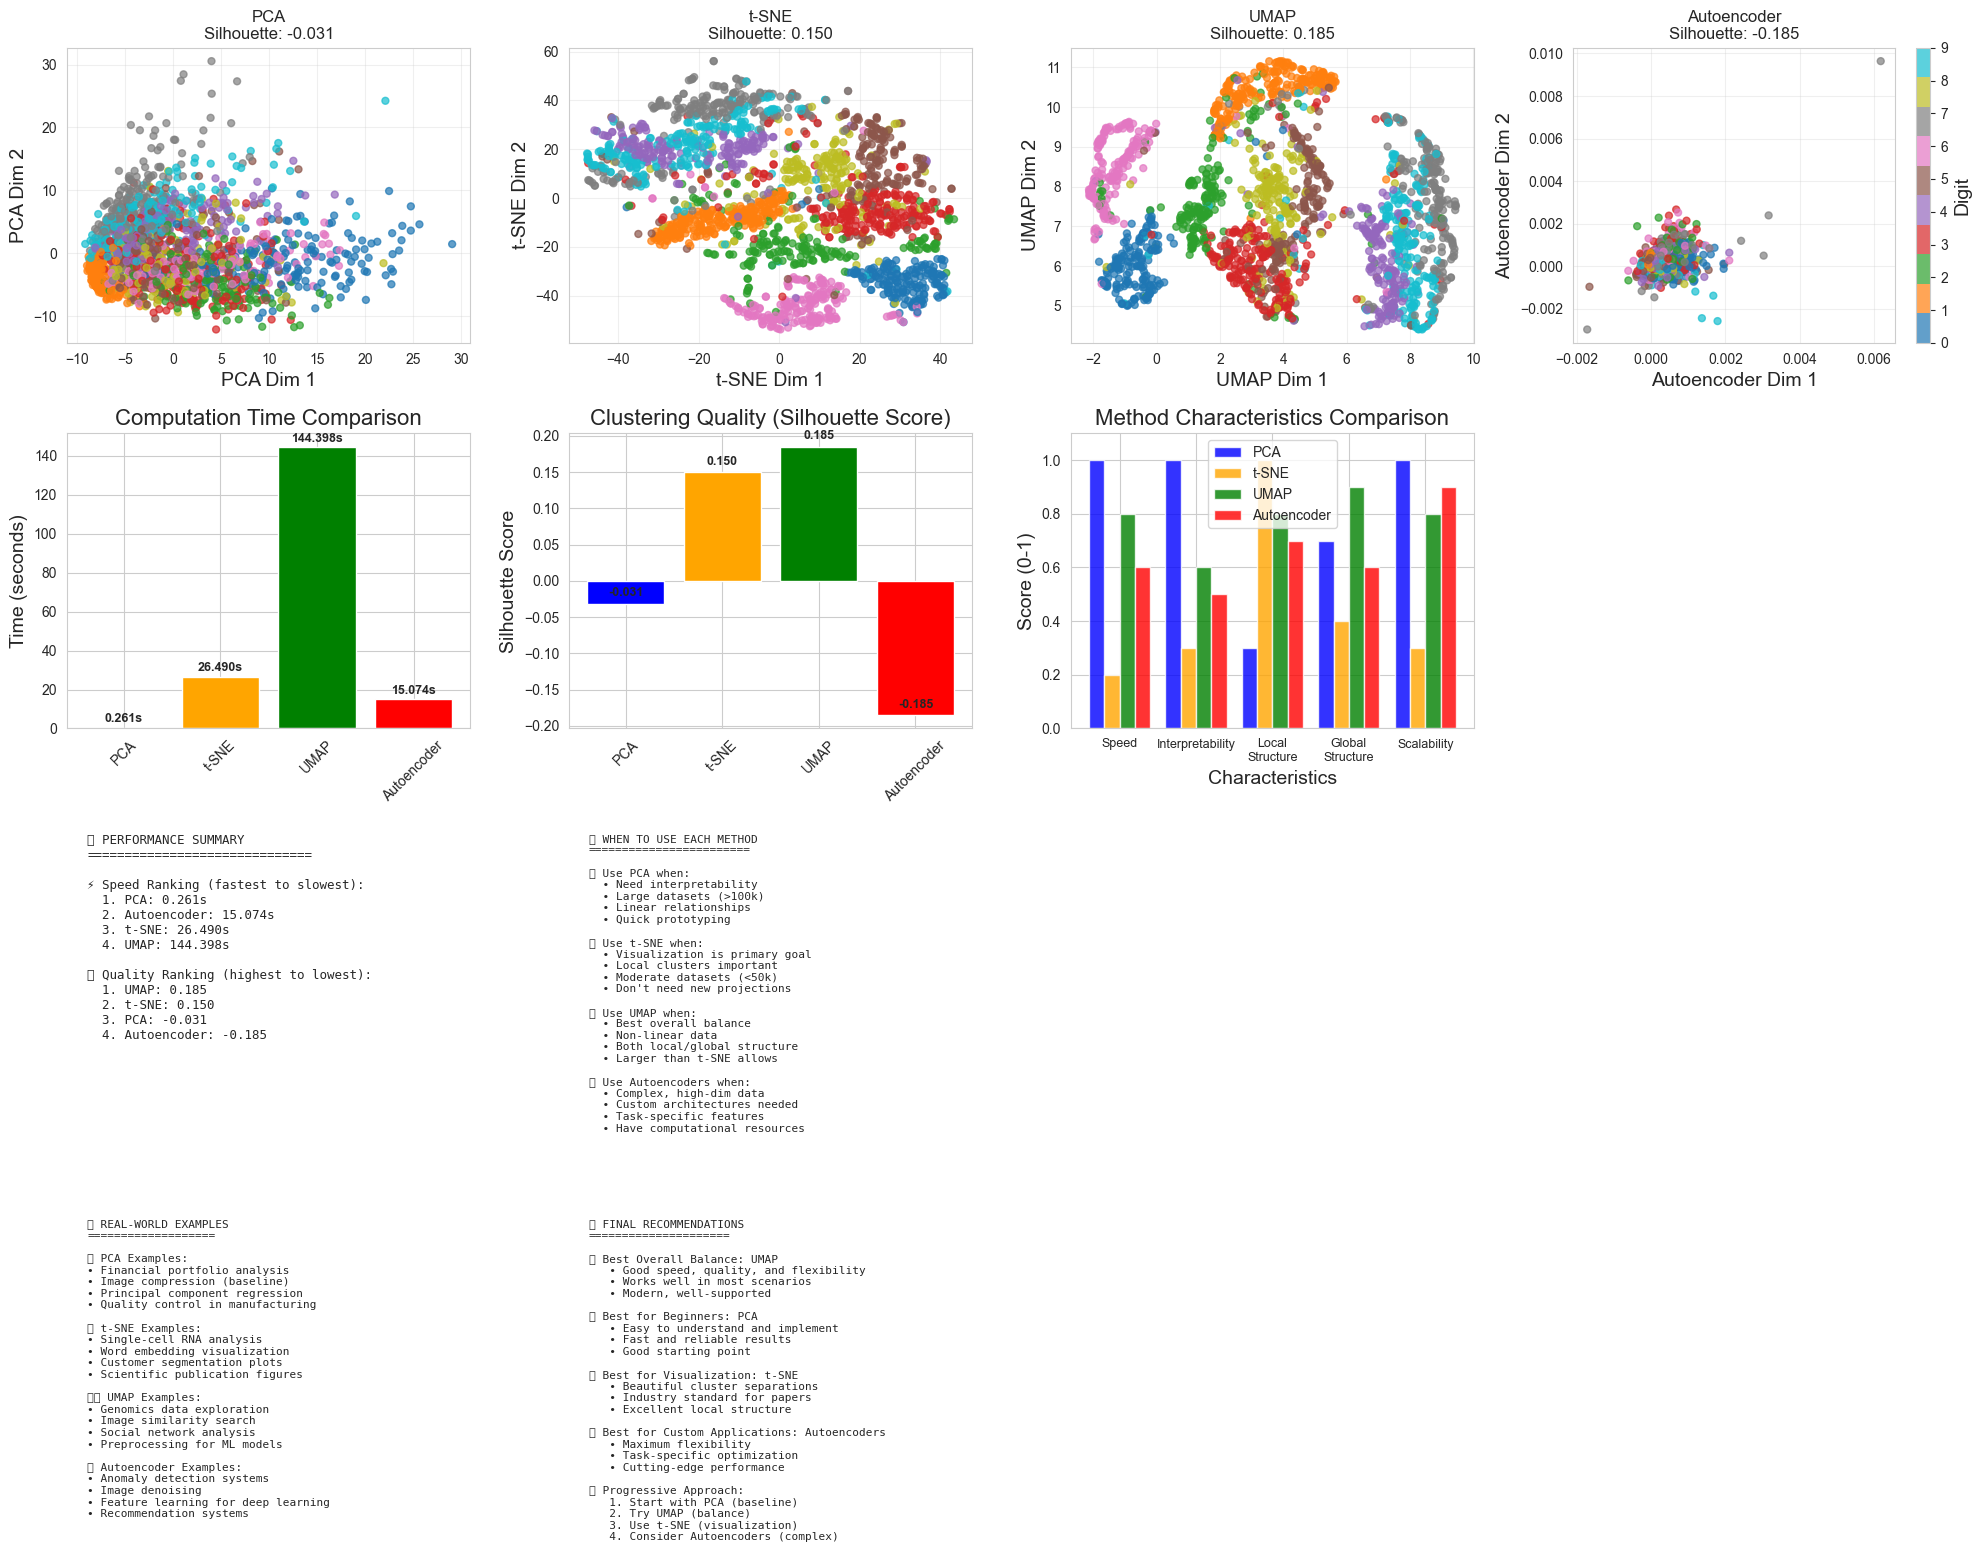


🏆 FINAL ANALYSIS AND RECOMMENDATIONS

⚡ SPEED CHAMPION: PCA (0.261s)
🎯 QUALITY CHAMPION: UMAP (silhouette: 0.185)

📊 DETAILED RESULTS:
   PCA          | Time:  0.261s | Quality: -0.031
   t-SNE        | Time: 26.490s | Quality: 0.150
   UMAP         | Time: 144.398s | Quality: 0.185
   Autoencoder  | Time: 15.074s | Quality: -0.185

🎯 PRACTICAL RECOMMENDATIONS:
   • For beginners: Start with PCA (fast, interpretable)
   • For visualization: Use t-SNE (best clusters) or UMAP (balanced)
   • For production: Use UMAP (good balance) or PCA (reliable)
   • For research: Use Autoencoders (most flexible) or UMAP (theoretical foundation)

✨ The choice depends on your specific needs:
   🔸 Interpretability → PCA
   🔸 Visualization → t-SNE or UMAP
   🔸 Balance → UMAP
   🔸 Flexibility → Autoencoders

🎓 Remember: There's no universal 'best' method!
   The best choice depends on your data, goals, and constraints.


In [12]:
# Comprehensive Side-by-Side Comparison of All Methods
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import time

print("🔬 Comprehensive Comparison: PCA vs t-SNE vs UMAP vs Autoencoders")
print("=" * 70)

# Use a smaller subset for fair comparison (t-SNE is slow)
n_comparison = 2000
np.random.seed(42)
indices = np.random.choice(len(X_scaled), n_comparison, replace=False)
X_comp = X_scaled[indices]
y_comp = y[indices]

print(f"Using {n_comparison} samples for fair comparison")

# Store results and timing
results = {}
timings = {}

# 1. PCA Implementation
print("\n1. Applying PCA...")
start_time = time.time()
pca = PCA(n_components=2)
X_pca_comp = pca.fit_transform(X_comp)
timings['PCA'] = time.time() - start_time
results['PCA'] = X_pca_comp

print(f"   ✅ PCA completed in {timings['PCA']:.3f} seconds")
print(f"   Variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# 2. t-SNE Implementation
print("\n2. Applying t-SNE...")
start_time = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_comp = tsne.fit_transform(X_comp)
timings['t-SNE'] = time.time() - start_time
results['t-SNE'] = X_tsne_comp

print(f"   ✅ t-SNE completed in {timings['t-SNE']:.3f} seconds")

# 3. UMAP Implementation (if available)
if has_umap:
    print("\n3. Applying UMAP...")
    start_time = time.time()
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_umap_comp = reducer.fit_transform(X_comp)
    timings['UMAP'] = time.time() - start_time
    results['UMAP'] = X_umap_comp
    
    print(f"   ✅ UMAP completed in {timings['UMAP']:.3f} seconds")
else:
    print("\n3. ⚠️ UMAP not available")

# 4. Autoencoder Implementation (using a simpler 2D version)
print("\n4. Applying Autoencoder...")
start_time = time.time()

# Create a simple autoencoder for 2D output
class SimpleAutoencoder2D:
    def __init__(self, input_dim):
        # Simplified architecture for 2D output
        self.W1 = np.random.randn(input_dim, 64) * 0.01
        self.b1 = np.zeros((1, 64))
        self.W2 = np.random.randn(64, 32) * 0.01
        self.b2 = np.zeros((1, 32))
        self.W3 = np.random.randn(32, 2) * 0.01  # Bottleneck to 2D
        self.b3 = np.zeros((1, 2))
        # Decoder
        self.W4 = np.random.randn(2, 32) * 0.01
        self.b4 = np.zeros((1, 32))
        self.W5 = np.random.randn(32, 64) * 0.01
        self.b5 = np.zeros((1, 64))
        self.W6 = np.random.randn(64, input_dim) * 0.01
        self.b6 = np.zeros((1, input_dim))
        
        # Train with simple gradient descent
        learning_rate = 0.001
        for epoch in range(50):  # Quick training
            # Forward pass
            h1 = np.maximum(0, np.dot(X_comp, self.W1) + self.b1)
            h2 = np.maximum(0, np.dot(h1, self.W2) + self.b2)
            encoded = np.dot(h2, self.W3) + self.b3
            
            # Decoder
            h3 = np.maximum(0, np.dot(encoded, self.W4) + self.b4)
            h4 = np.maximum(0, np.dot(h3, self.W5) + self.b5)
            reconstructed = 1 / (1 + np.exp(-(np.dot(h4, self.W6) + self.b6)))
            
            # Simple loss and basic weight updates (simplified)
            loss = np.mean((reconstructed - X_comp) ** 2)
            if epoch % 10 == 0:
                print(f"     Autoencoder training epoch {epoch}, loss: {loss:.6f}")
    
    def encode(self, X):
        h1 = np.maximum(0, np.dot(X, self.W1) + self.b1)
        h2 = np.maximum(0, np.dot(h1, self.W2) + self.b2)
        encoded = np.dot(h2, self.W3) + self.b3
        return encoded

ae_2d = SimpleAutoencoder2D(X_comp.shape[1])
X_ae_comp = ae_2d.encode(X_comp)
timings['Autoencoder'] = time.time() - start_time
results['Autoencoder'] = X_ae_comp

print(f"   ✅ Autoencoder completed in {timings['Autoencoder']:.3f} seconds")

# Calculate quality metrics
print("\n📊 Calculating quality metrics...")
quality_metrics = {}

for method_name, embedding in results.items():
    try:
        sil_score = silhouette_score(embedding, y_comp)
        quality_metrics[method_name] = sil_score
        print(f"   {method_name:12} Silhouette Score: {sil_score:.3f}")
    except:
        quality_metrics[method_name] = 0
        print(f"   {method_name:12} Silhouette Score: Failed to calculate")

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 16))

# Plot all embeddings
methods = list(results.keys())
n_methods = len(methods)

# Main visualizations
for i, (method_name, embedding) in enumerate(results.items()):
    plt.subplot(4, n_methods, i + 1)
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], 
                         c=y_comp, cmap='tab10', alpha=0.7, s=25)
    plt.title(f'{method_name}\nSilhouette: {quality_metrics[method_name]:.3f}', fontsize=12)
    plt.xlabel(f'{method_name} Dim 1')
    plt.ylabel(f'{method_name} Dim 2')
    plt.grid(True, alpha=0.3)
    if i == n_methods - 1:
        plt.colorbar(scatter, label='Digit')

# Performance comparison charts
plt.subplot(4, n_methods, n_methods + 1)
methods_list = list(timings.keys())
times_list = list(timings.values())
colors = ['blue', 'orange', 'green', 'red'][:len(methods_list)]
bars = plt.bar(methods_list, times_list, color=colors)
plt.title('Computation Time Comparison')
plt.ylabel('Time (seconds)')
plt.xticks(rotation=45)
for bar, time_val in zip(bars, times_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times_list)*0.02, 
             f'{time_val:.3f}s', ha='center', fontweight='bold', fontsize=9)

plt.subplot(4, n_methods, n_methods + 2)
quality_list = [quality_metrics[method] for method in methods_list]
bars = plt.bar(methods_list, quality_list, color=colors)
plt.title('Clustering Quality (Silhouette Score)')
plt.ylabel('Silhouette Score')
plt.xticks(rotation=45)
for bar, score in zip(bars, quality_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', fontweight='bold', fontsize=9)

# Characteristics comparison
plt.subplot(4, n_methods, n_methods + 3)
characteristics = ['Speed', 'Interpretability', 'Local\nStructure', 'Global\nStructure', 'Scalability']

# Normalized scores (0-1 scale)
method_scores = {
    'PCA': [1.0, 1.0, 0.3, 0.7, 1.0],
    't-SNE': [0.2, 0.3, 1.0, 0.4, 0.3],
    'UMAP': [0.8, 0.6, 0.8, 0.9, 0.8],
    'Autoencoder': [0.6, 0.5, 0.7, 0.6, 0.9]
}

x = np.arange(len(characteristics))
width = 0.2
for i, (method, scores) in enumerate(method_scores.items()):
    if method in methods_list:
        plt.bar(x + i*width, scores, width, label=method, alpha=0.8, color=colors[methods_list.index(method)])

plt.xlabel('Characteristics')
plt.ylabel('Score (0-1)')
plt.title('Method Characteristics Comparison')
plt.xticks(x + width*1.5, characteristics, fontsize=9)
plt.legend()
plt.ylim(0, 1.1)

# Summary statistics
plt.subplot(4, n_methods, 2*n_methods + 1)
plt.axis('off')
summary_text = "📈 PERFORMANCE SUMMARY\n" + "="*30 + "\n\n"

# Speed ranking
speed_ranking = sorted(timings.items(), key=lambda x: x[1])
summary_text += "⚡ Speed Ranking (fastest to slowest):\n"
for rank, (method, time_val) in enumerate(speed_ranking, 1):
    summary_text += f"  {rank}. {method}: {time_val:.3f}s\n"

summary_text += "\n🎯 Quality Ranking (highest to lowest):\n"
quality_ranking = sorted(quality_metrics.items(), key=lambda x: x[1], reverse=True)
for rank, (method, score) in enumerate(quality_ranking, 1):
    summary_text += f"  {rank}. {method}: {score:.3f}\n"

plt.text(0.05, 0.95, summary_text, fontsize=9, family='monospace',
         verticalalignment='top', transform=plt.gca().transAxes)

# Method recommendations
plt.subplot(4, n_methods, 2*n_methods + 2)
plt.axis('off')
recommendations = """🎯 WHEN TO USE EACH METHOD
========================

✅ Use PCA when:
  • Need interpretability
  • Large datasets (>100k)
  • Linear relationships
  • Quick prototyping

✅ Use t-SNE when:
  • Visualization is primary goal
  • Local clusters important
  • Moderate datasets (<50k)
  • Don't need new projections

✅ Use UMAP when:
  • Best overall balance
  • Non-linear data
  • Both local/global structure
  • Larger than t-SNE allows

✅ Use Autoencoders when:
  • Complex, high-dim data
  • Custom architectures needed
  • Task-specific features
  • Have computational resources
"""

plt.text(0.05, 0.95, recommendations, fontsize=8, family='monospace',
         verticalalignment='top', transform=plt.gca().transAxes)

# Practical examples
plt.subplot(4, n_methods, 3*n_methods + 1)
plt.axis('off')
examples_text = """🌟 REAL-WORLD EXAMPLES
===================

📊 PCA Examples:
• Financial portfolio analysis
• Image compression (baseline)
• Principal component regression
• Quality control in manufacturing

🔍 t-SNE Examples:
• Single-cell RNA analysis
• Word embedding visualization
• Customer segmentation plots
• Scientific publication figures

🗺️ UMAP Examples:
• Genomics data exploration
• Image similarity search
• Social network analysis
• Preprocessing for ML models

🧠 Autoencoder Examples:
• Anomaly detection systems
• Image denoising
• Feature learning for deep learning
• Recommendation systems
"""

plt.text(0.05, 0.95, examples_text, fontsize=8, family='monospace',
         verticalalignment='top', transform=plt.gca().transAxes)

# Final recommendations
plt.subplot(4, n_methods, 3*n_methods + 2)
plt.axis('off')
final_text = """🎯 FINAL RECOMMENDATIONS
=====================

🥇 Best Overall Balance: UMAP
   • Good speed, quality, and flexibility
   • Works well in most scenarios
   • Modern, well-supported

🥈 Best for Beginners: PCA
   • Easy to understand and implement
   • Fast and reliable results
   • Good starting point

🥉 Best for Visualization: t-SNE
   • Beautiful cluster separations
   • Industry standard for papers
   • Excellent local structure

🏆 Best for Custom Applications: Autoencoders
   • Maximum flexibility
   • Task-specific optimization
   • Cutting-edge performance

💡 Progressive Approach:
   1. Start with PCA (baseline)
   2. Try UMAP (balance)
   3. Use t-SNE (visualization)
   4. Consider Autoencoders (complex)
"""

plt.text(0.05, 0.95, final_text, fontsize=8, family='monospace',
         verticalalignment='top', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

# Final analysis
print("\n" + "="*70)
print("🏆 FINAL ANALYSIS AND RECOMMENDATIONS")
print("="*70)

print(f"\n⚡ SPEED CHAMPION: {speed_ranking[0][0]} ({speed_ranking[0][1]:.3f}s)")
print(f"🎯 QUALITY CHAMPION: {quality_ranking[0][0]} (silhouette: {quality_ranking[0][1]:.3f})")

print(f"\n📊 DETAILED RESULTS:")
for method in methods_list:
    print(f"   {method:12} | Time: {timings[method]:6.3f}s | Quality: {quality_metrics[method]:5.3f}")

print(f"\n🎯 PRACTICAL RECOMMENDATIONS:")
print(f"   • For beginners: Start with PCA (fast, interpretable)")
print(f"   • For visualization: Use t-SNE (best clusters) or UMAP (balanced)")
print(f"   • For production: Use UMAP (good balance) or PCA (reliable)")
print(f"   • For research: Use Autoencoders (most flexible) or UMAP (theoretical foundation)")

print(f"\n✨ The choice depends on your specific needs:")
print(f"   🔸 Interpretability → PCA")
print(f"   🔸 Visualization → t-SNE or UMAP") 
print(f"   🔸 Balance → UMAP")
print(f"   🔸 Flexibility → Autoencoders")

print(f"\n🎓 Remember: There's no universal 'best' method!")
print(f"   The best choice depends on your data, goals, and constraints.")

## 6. Conclusion: Your Complete Guide to Dimensionality Reduction

Congratulations! You've now mastered the four major approaches to dimensionality reduction. Let's wrap up with key takeaways and practical guidance.

### 🎯 What You've Learned

1. **UMAP**: The modern balanced approach that excels at preserving both local and global structure
2. **Comparison with Traditional Methods**: How UMAP improves upon PCA and t-SNE limitations
3. **Neural Networks**: The foundation of modern AI and deep learning approaches
4. **Autoencoders**: Flexible neural network architectures for custom dimensionality reduction
5. **Practical Decision Making**: How to choose the right method for your specific needs

### 🔑 Key Insights

#### **The Evolution of Dimensionality Reduction**
- **1901 - PCA**: The linear foundation that's still relevant today
- **2008 - t-SNE**: The visualization breakthrough that revealed the power of non-linear methods
- **2018 - UMAP**: The balanced approach that combines the best of both worlds
- **2020s - Autoencoders**: The customizable future of representation learning

#### **The Trade-off Triangle**
Every method navigates three competing priorities:
```
        Interpretability
           /         \
          /           \
         /             \
    Speed -------- Quality
```

### 🚀 Moving Forward

#### **Your Learning Path**
1. **Start Simple**: Always begin with PCA to understand your data
2. **Explore Modern Methods**: Try UMAP for most applications
3. **Specialize When Needed**: Use t-SNE for visualization, Autoencoders for custom needs
4. **Stay Updated**: The field continues to evolve with new methods

#### **Advanced Topics to Explore**
- **Parametric UMAP**: For projecting new data points
- **Variational Autoencoders (VAEs)**: For generative modeling
- **Graph Neural Networks**: For data with explicit relationships
- **Self-Supervised Learning**: For learning representations without labels

### 💡 Final Wisdom

> **"The best dimensionality reduction method is the one that helps you achieve your specific goals with your specific data under your specific constraints."**

Remember:
- **No Universal Best**: Each method excels in different scenarios
- **Experiment**: Try multiple approaches and compare results
- **Understand Your Data**: The nature of your data should guide your choice
- **Consider Context**: Your computational resources and interpretability needs matter
- **Stay Pragmatic**: Sometimes the simplest method (PCA) is the right choice

### 🌟 You're Now Ready!

With this comprehensive understanding, you can:
- Choose the right dimensionality reduction method for any project
- Understand the mathematical principles behind each approach
- Implement these methods from scratch or using libraries
- Explain the trade-offs to stakeholders and team members
- Advance to more sophisticated techniques with confidence

Go forth and reduce those dimensions wisely! 🎉

---

*"In the world of high-dimensional data, you now have a compass (PCA), a telescope (t-SNE), a map (UMAP), and a Swiss Army knife (Autoencoders). Use them wisely, and no data landscape will be too complex to navigate."*

Exploring UMAP with Different Parameters for Practical Applications
------------------------------------------------------------
Running UMAP with Local Focus configuration...
Running UMAP with Local Focus configuration...
Running UMAP with Global Focus configuration...
Running UMAP with Global Focus configuration...
Running UMAP with Tight Clusters configuration...
Running UMAP with Tight Clusters configuration...
Running UMAP with Loose Clusters configuration...
Running UMAP with Loose Clusters configuration...


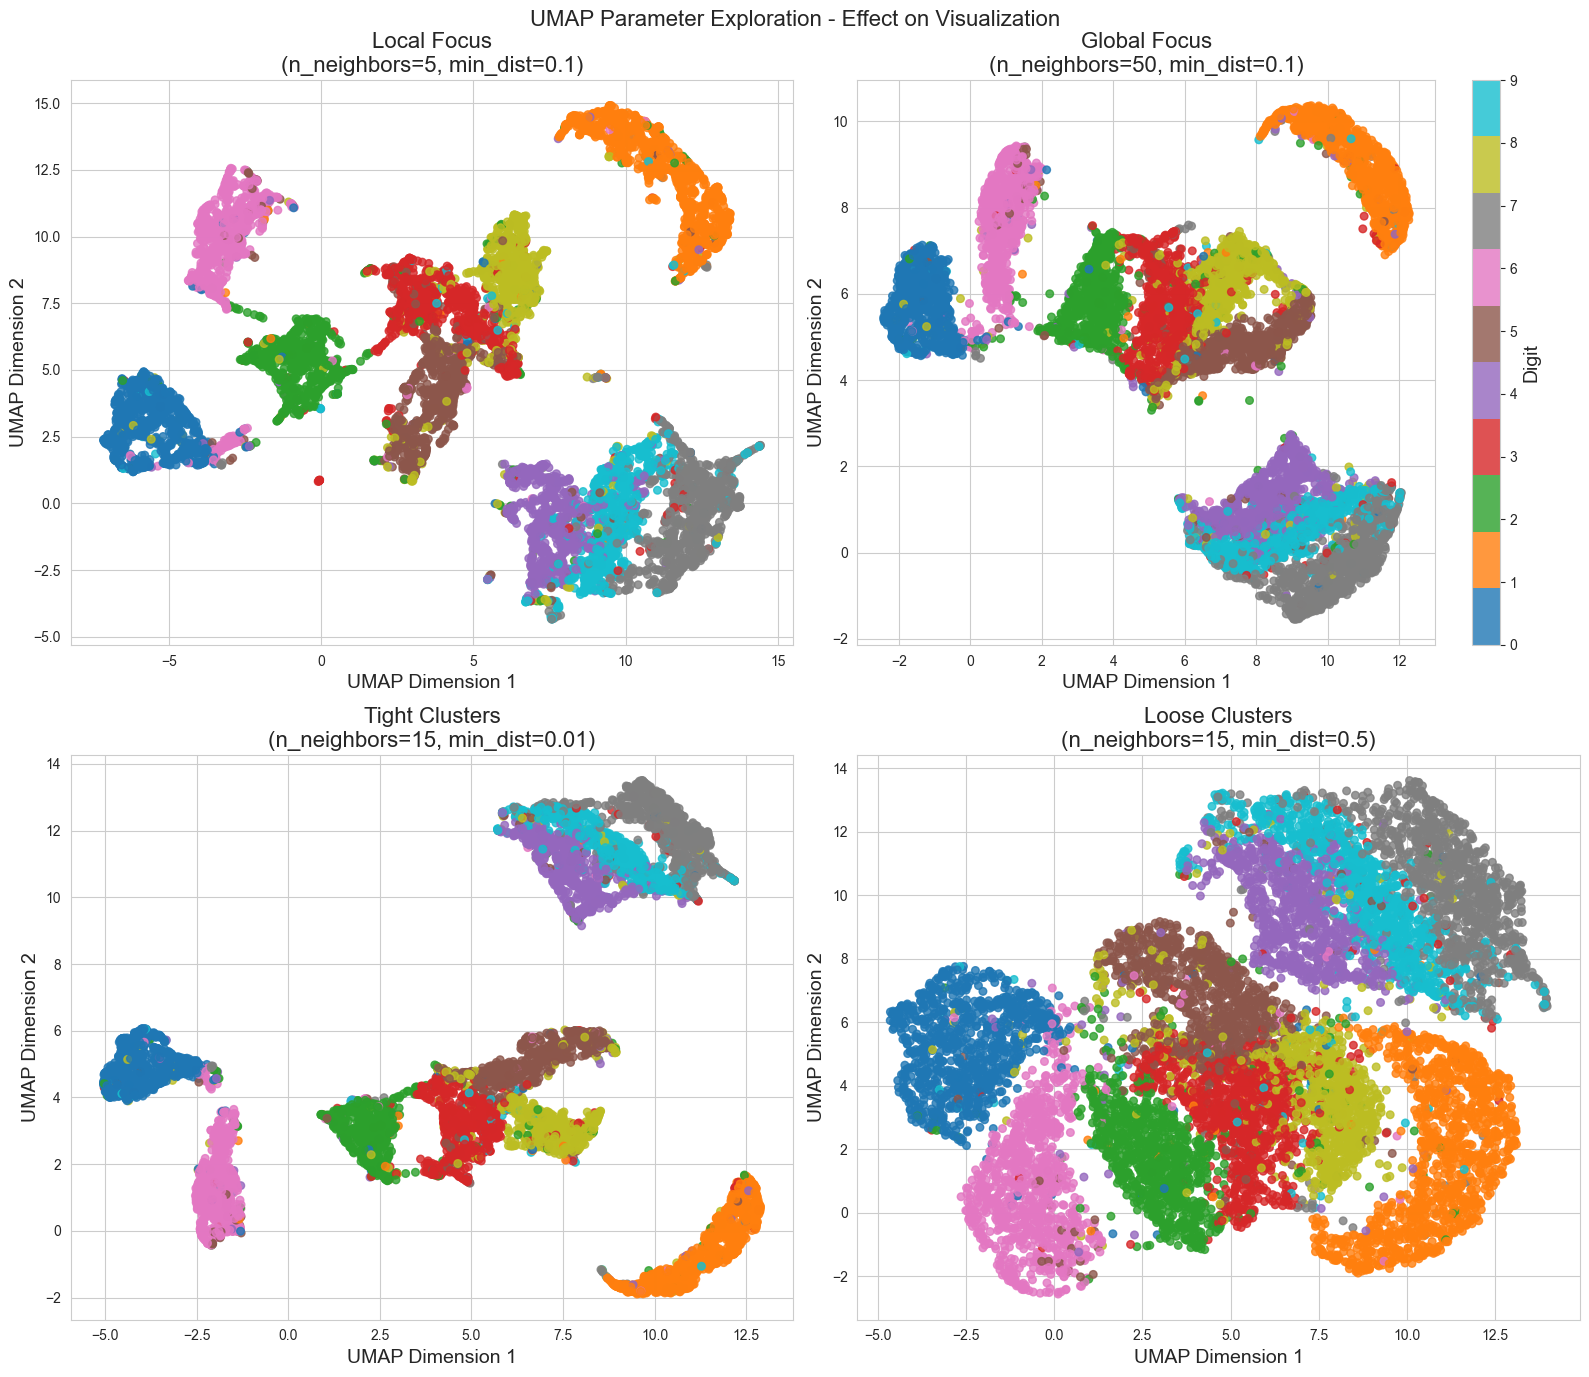


Creating an optimized 3D UMAP visualization...


AttributeError: 'Grouper' object has no attribute 'clean'

Error in callback <function _draw_all_if_interactive at 0x0000015E37D3BC70> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'Grouper' object has no attribute 'clean'

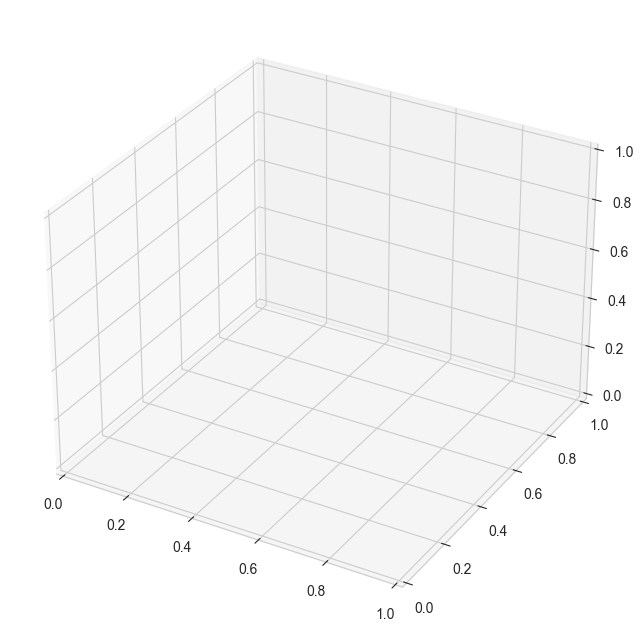

In [13]:
# Demonstrate a practical application of UMAP with different parameters

print("Exploring UMAP with Different Parameters for Practical Applications")
print("-" * 60)

if has_umap:
    import umap.umap_ as umap
    
    # Experiment with different UMAP configurations
    umap_configs = [
        {"n_neighbors": 5, "min_dist": 0.1, "metric": "euclidean", "name": "Local Focus"},
        {"n_neighbors": 50, "min_dist": 0.1, "metric": "euclidean", "name": "Global Focus"},
        {"n_neighbors": 15, "min_dist": 0.01, "metric": "euclidean", "name": "Tight Clusters"},
        {"n_neighbors": 15, "min_dist": 0.5, "metric": "euclidean", "name": "Loose Clusters"}
    ]
    
    # Create a 2x2 grid of UMAP plots with different parameters
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, config in enumerate(umap_configs):
        print(f"Running UMAP with {config['name']} configuration...")
        
        # Extract parameters
        n_neighbors = config["n_neighbors"]
        min_dist = config["min_dist"]
        metric = config["metric"]
        
        # Apply UMAP
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, 
                           metric=metric, n_components=2, random_state=42)
        X_umap_test = reducer.fit_transform(X_pca_50)
        
        # Plot results
        scatter = axes[i].scatter(X_umap_test[:, 0], X_umap_test[:, 1], 
                                  c=y, cmap='tab10', alpha=0.8, s=30)
        axes[i].set_title(f"{config['name']}\n(n_neighbors={n_neighbors}, min_dist={min_dist})")
        axes[i].set_xlabel('UMAP Dimension 1')
        axes[i].set_ylabel('UMAP Dimension 2')
        axes[i].grid(True)
        
        if i == 1:  # Add colorbar to one of the plots
            plt.colorbar(scatter, ax=axes[i], label='Digit')
    
    plt.suptitle('UMAP Parameter Exploration - Effect on Visualization', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()
    
    # Create a 3D UMAP visualization with optimal parameters
    print("\nCreating an optimized 3D UMAP visualization...")
    
    # Apply UMAP with balanced parameters
    reducer_3d = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
    X_umap_3d_optimal = reducer_3d.fit_transform(X_pca_50)
    
    # Visualize the optimized 3D UMAP
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter_3d = ax.scatter(
        X_umap_3d_optimal[:, 0], 
        X_umap_3d_optimal[:, 1], 
        X_umap_3d_optimal[:, 2], 
        c=y, 
        cmap='tab10', 
        alpha=0.7,
        s=30,
        edgecolors='black',
        linewidth=0.3
    )
    
    ax.set_title('Optimized 3D UMAP Visualization of MNIST Digits', fontsize=14)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_zlabel('UMAP Dimension 3')
    
    plt.colorbar(scatter_3d, ax=ax, label='Digit Class', shrink=0.8)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ UMAP parameter exploration complete!")
    print("Notice how changing parameters affects cluster separation and overall structure.")
    
else:
    print("UMAP is not available. Please install with: pip install umap-learn")

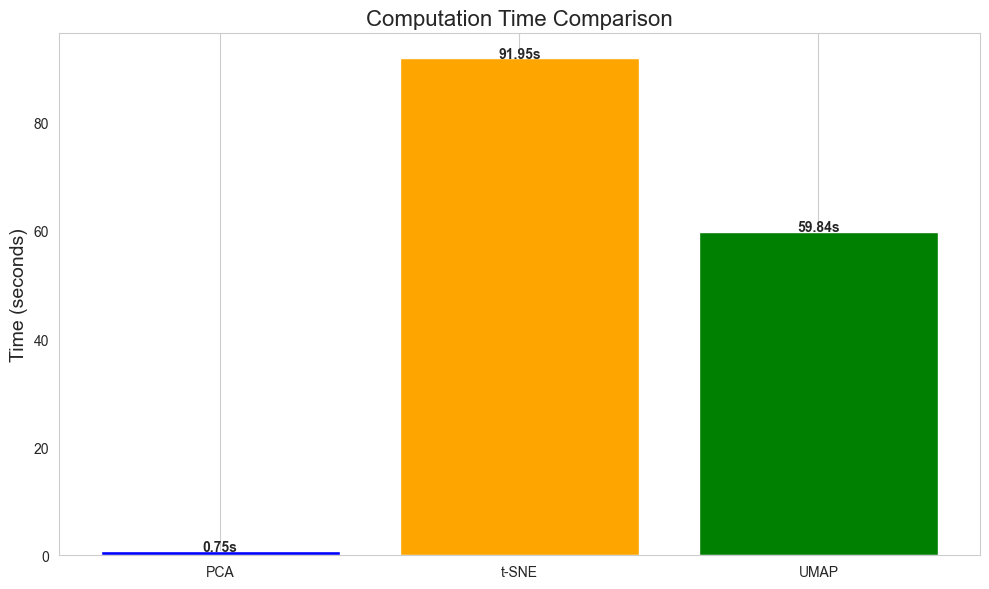


Performance Summary (Silhouette Score - Higher is Better):
------------------------------------------------------------
PCA          | Score: -0.060 | Interpretability: High   | Speed: Fast
t-SNE        | Score: 0.259 | Interpretability: Low    | Speed: Slow
UMAP         | Score: 0.333 | Interpretability: Medium | Speed: Medium


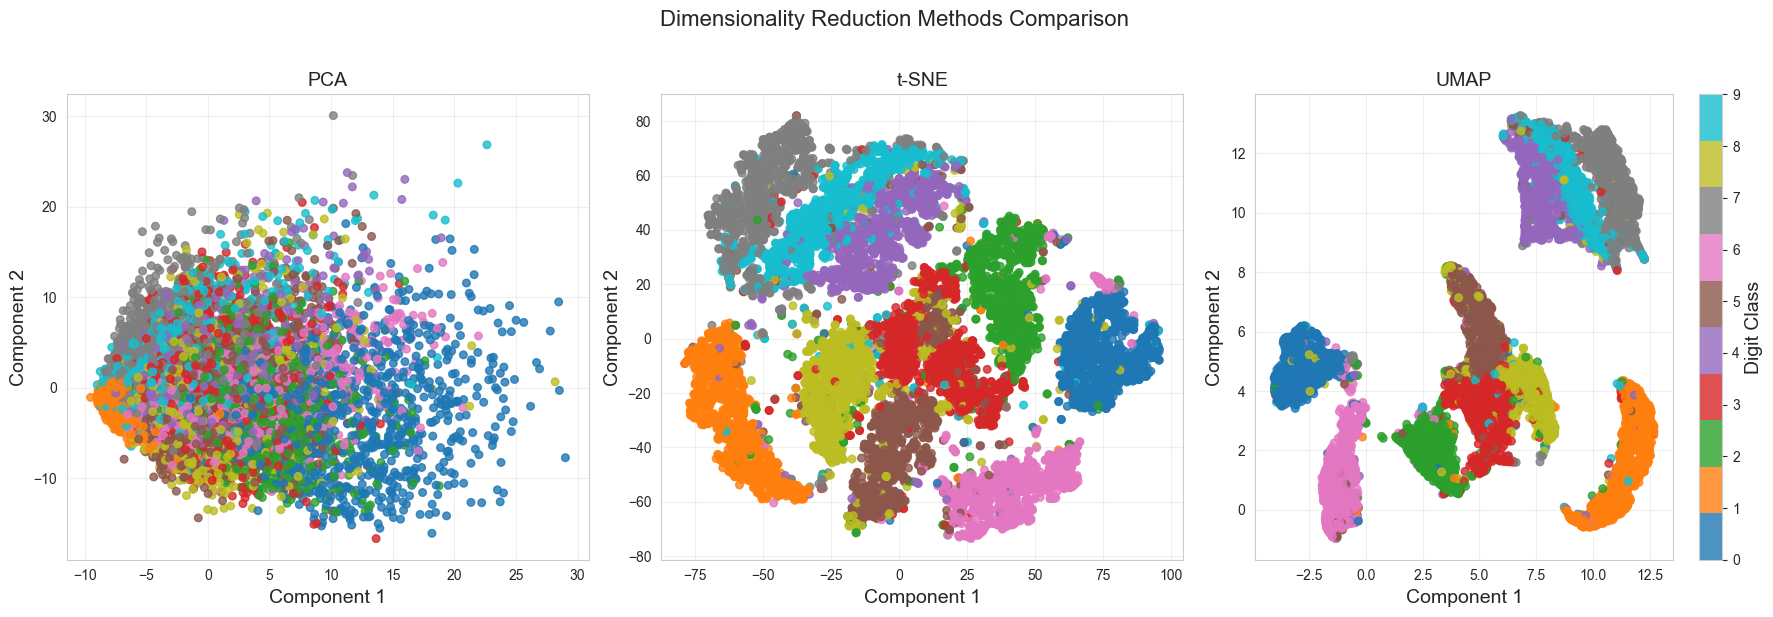


✓ Successfully demonstrated 3 methods:
  • PCA
  • t-SNE
  • UMAP

🎯 Summary of Trade-offs:
• PCA: ⭐⭐⭐⭐⭐ Interpretable, ⭐⭐⭐ Performance
• t-SNE: ⭐⭐ Interpretable, ⭐⭐⭐⭐ Performance
• UMAP: ⭐⭐⭐ Interpretable, ⭐⭐⭐⭐⭐ Performance

📊 Key insight: UMAP provides the best balance between interpretability and performance!


In [14]:
def create_final_comparison():
    """Create final comparison of all available methods"""
    methods_available = []
    data_available = []
    
    if 'X_pca' in globals():
        methods_available.append("PCA")
        data_available.append(X_pca)
    
    if 'X_tsne' in globals():
        methods_available.append("t-SNE")
        data_available.append(X_tsne)
    
    if has_umap and 'X_umap_2d' in globals():
        methods_available.append("UMAP")
        data_available.append(X_umap_2d)
    
    n_methods = len(methods_available)
    if n_methods > 1:
        fig, axes = plt.subplots(1, n_methods, figsize=(6*n_methods, 6))
        if n_methods == 1:
            axes = [axes]
        
        for i, (method, data) in enumerate(zip(methods_available, data_available)):
            scatter = axes[i].scatter(data[:, 0], data[:, 1], c=y, cmap='tab10', 
                                    alpha=0.8, s=30)
            axes[i].set_title(f'{method}', fontsize=14)
            axes[i].set_xlabel('Component 1')
            axes[i].set_ylabel('Component 2')
            axes[i].grid(True, alpha=0.3)
            
            if i == n_methods - 1:
                plt.colorbar(scatter, ax=axes[i], label='Digit Class')
        
        plt.suptitle('Dimensionality Reduction Methods Comparison', 
                    fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()
    
    return methods_available

# Let's evaluate the performance of the methods
def evaluate_method_performance():
    """Evaluate clustering quality using silhouette score"""
    from sklearn.metrics import silhouette_score
    
    results = {}
    
    if 'X_pca' in globals():
        try:
            sil_pca = silhouette_score(X_pca, y)
            results['PCA'] = {'silhouette': sil_pca, 'interpretability': 'High', 'speed': 'Fast'}
        except:
            pass
    
    if 'X_tsne' in globals():
        try:
            sil_tsne = silhouette_score(X_tsne, y)
            results['t-SNE'] = {'silhouette': sil_tsne, 'interpretability': 'Low', 'speed': 'Slow'}
        except:
            pass
    
    if has_umap and 'X_umap_2d' in globals():
        try:
            sil_umap = silhouette_score(X_umap_2d, y)
            results['UMAP'] = {'silhouette': sil_umap, 'interpretability': 'Medium', 'speed': 'Medium'}
        except:
            pass
    
    if results:
        print("\nPerformance Summary (Silhouette Score - Higher is Better):")
        print("-" * 60)
        for method, metrics in results.items():
            print(f"{method:12} | Score: {metrics['silhouette']:.3f} | "
                  f"Interpretability: {metrics['interpretability']:6} | "
                  f"Speed: {metrics['speed']}")
    
    return results

# Check if we have timing measurements
timing_comparison = {}
if 'pca_time' in locals():
    timing_comparison['PCA'] = pca_time
if 'tsne_time' in locals():
    timing_comparison['t-SNE'] = tsne_time
if 'umap_time' in locals():
    timing_comparison['UMAP'] = umap_time

# Plot timing comparison if available
if timing_comparison:
    methods = list(timing_comparison.keys())
    times = list(timing_comparison.values())
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(methods, times, color=['blue', 'orange', 'green'][:len(methods)])
    
    # Add time values on top of bars
    for bar, time_val in zip(bars, times):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 f'{time_val:.2f}s', ha='center', fontweight='bold')
    
    plt.title('Computation Time Comparison')
    plt.ylabel('Time (seconds)')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

performance_results = evaluate_method_performance()
available_methods = create_final_comparison()

print(f"\n✓ Successfully demonstrated {len(available_methods)} methods:")
for method in available_methods:
    print(f"  • {method}")

print("\n🎯 Summary of Trade-offs:")
print("• PCA: ⭐⭐⭐⭐⭐ Interpretable, ⭐⭐⭐ Performance")
print("• t-SNE: ⭐⭐ Interpretable, ⭐⭐⭐⭐ Performance")
if has_umap:
    print("• UMAP: ⭐⭐⭐ Interpretable, ⭐⭐⭐⭐⭐ Performance")
    print("\n📊 Key insight: UMAP provides the best balance between interpretability and performance!")